In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
from scipy.stats import multivariate_normal

In [2]:
import sklearn

In [3]:
def f(chi):
    return np.sqrt((1+np.sqrt(1-chi**2))/2)

In [4]:
sigma = 0.02
N_points = 10000

In [5]:
Mirr = []
chi = []
for i in range(10):
    chii = scipy.stats.uniform.rvs(0, 1, N_points)
    chi = np.append(chi,chii)
    M = norm.rvs(1,sigma,N_points)
    Mirri = M*f(chii)
    Mirr = np.append(Mirr, Mirri)

(array([0.0492548 , 0.31286847, 0.73354463, 1.24594528, 1.95637032,
        3.01660492, 5.09083492, 8.84249227, 3.76120675, 0.12087529]),
 array([0.68226044, 0.72205352, 0.7618466 , 0.80163968, 0.84143276,
        0.88122584, 0.92101892, 0.960812  , 1.00060508, 1.04039816,
        1.08019123]),
 <BarContainer object of 10 artists>)

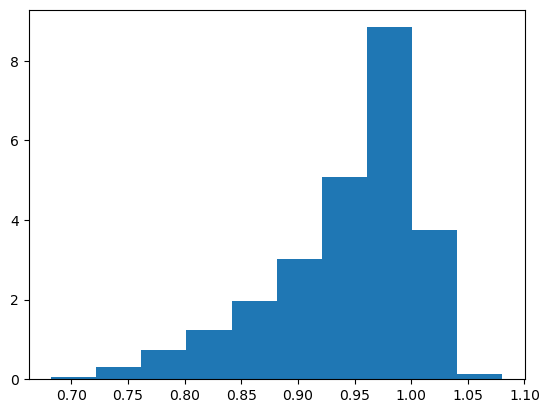

In [6]:
plt.hist(Mirr,density=True)

[]

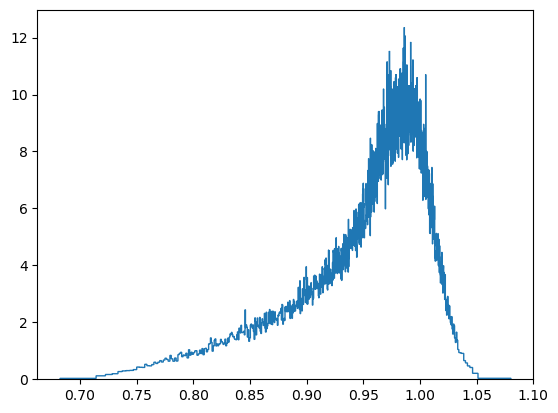

In [7]:
bins100 = np.append(np.sort(Mirr)[::100], np.max(Mirr)) 
plt.hist(Mirr, bins=bins100, density=True, histtype="step") 
plt.plot()

(array([8.61694307e-03, 8.61694307e-03, 1.43615718e-02, 0.00000000e+00,
        2.01062005e-02, 3.73400866e-02, 5.45739728e-02, 4.88293441e-02,
        8.32971163e-02, 8.32971163e-02, 1.20637203e-01, 1.52232661e-01,
        1.80955804e-01, 2.26912834e-01, 1.95317376e-01, 2.78614493e-01,
        3.13082265e-01, 3.10209950e-01, 2.72869864e-01, 4.13613267e-01,
        4.13613267e-01, 4.79676497e-01, 4.99782698e-01, 5.02655012e-01,
        6.08930644e-01, 6.14675272e-01, 6.69249245e-01, 7.00844703e-01,
        7.15206275e-01, 7.00844703e-01, 8.81800507e-01, 8.38715792e-01,
        8.55949678e-01, 9.27757537e-01, 9.36374480e-01, 9.53608366e-01,
        9.93820767e-01, 1.08573483e+00, 1.24083980e+00, 1.25520137e+00,
        1.29541377e+00, 1.26669063e+00, 1.31839229e+00, 1.57977290e+00,
        1.45626338e+00, 1.65158075e+00, 1.72338861e+00, 1.66881464e+00,
        1.78945184e+00, 1.74349481e+00, 1.87562127e+00, 1.98476922e+00,
        1.97615228e+00, 2.13987420e+00, 2.16572502e+00, 2.220299

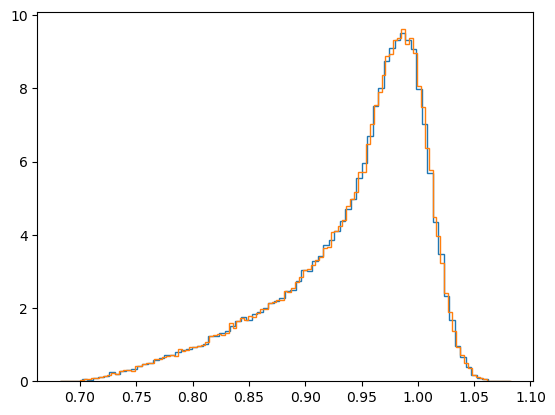

In [8]:
import astropy.visualization.hist
astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True)
astropy.visualization.hist(Mirr, bins="freedman", histtype="step",density=True)

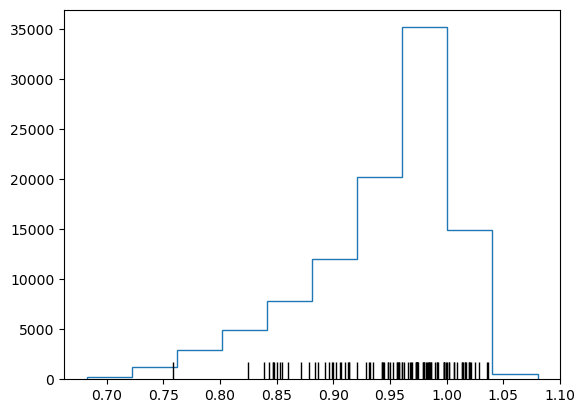

In [9]:
plt.hist(Mirr,histtype="step")
plt.plot(Mirr[:100], 0*Mirr[:100], '|', color='k', markersize=25);

In [10]:
from sklearn.neighbors import KernelDensity

In [11]:
xgrid = np.linspace(Mirr.min(),Mirr.max(),10000)

In [12]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

[]

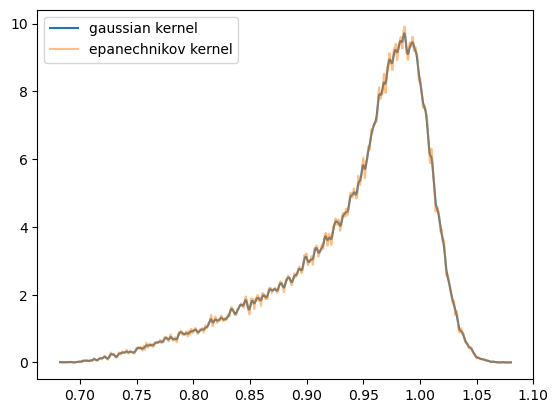

In [13]:
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="gaussian") 
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 0.5)
plt.legend()
plt.plot()

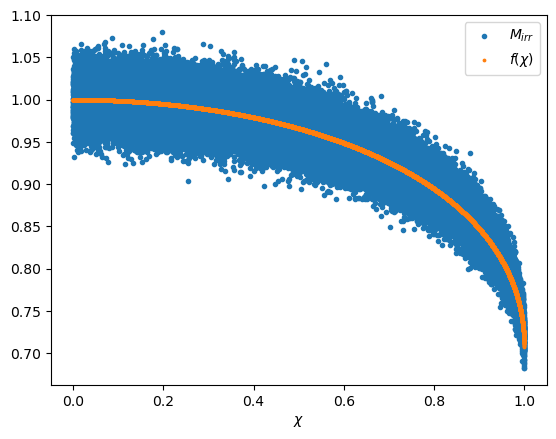

In [14]:
plt.scatter(chi,Mirr,marker='.', label=r'$M_{irr}$')
plt.scatter(chi,f(chi),s=3, label=r'$f(\chi)$')
plt.xlabel(r'$\chi$')
plt.legend()

In [15]:
print(stats.ks_2samp(Mirr,f(chi)))

KstestResult(statistic=0.15952999999999995, pvalue=0.0, statistic_location=0.9999999999986835, statistic_sign=-1)


In [16]:
N_sigma = 50
sigmas= np.logspace(-5,5,N_sigma)
sigmas

array([1.00000000e-05, 1.59985872e-05, 2.55954792e-05, 4.09491506e-05,
       6.55128557e-05, 1.04811313e-04, 1.67683294e-04, 2.68269580e-04,
       4.29193426e-04, 6.86648845e-04, 1.09854114e-03, 1.75751062e-03,
       2.81176870e-03, 4.49843267e-03, 7.19685673e-03, 1.15139540e-02,
       1.84206997e-02, 2.94705170e-02, 4.71486636e-02, 7.54312006e-02,
       1.20679264e-01, 1.93069773e-01, 3.08884360e-01, 4.94171336e-01,
       7.90604321e-01, 1.26485522e+00, 2.02358965e+00, 3.23745754e+00,
       5.17947468e+00, 8.28642773e+00, 1.32571137e+01, 2.12095089e+01,
       3.39322177e+01, 5.42867544e+01, 8.68511374e+01, 1.38949549e+02,
       2.22299648e+02, 3.55648031e+02, 5.68986603e+02, 9.10298178e+02,
       1.45634848e+03, 2.32995181e+03, 3.72759372e+03, 5.96362332e+03,
       9.54095476e+03, 1.52641797e+04, 2.44205309e+04, 3.90693994e+04,
       6.25055193e+04, 1.00000000e+05])

Text(0.5, 0, '$M_{irr}$')

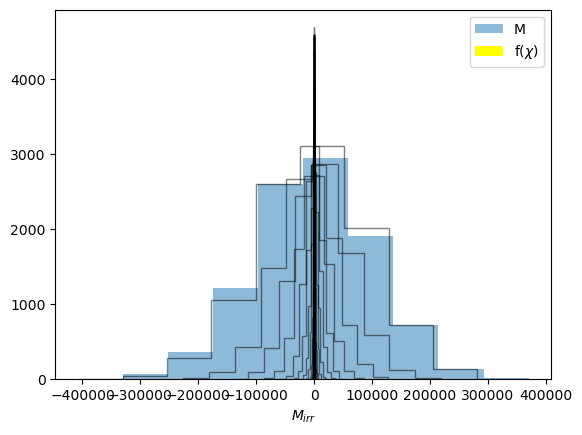

In [17]:
KSs_f = []
KSs_M = []

for sigmai in sigmas:
    chi = scipy.stats.uniform.rvs(0, 1, N_points)
    M = norm.rvs(1,sigmai,N_points)
    Mirri = M*f(chi)
    plt.hist(Mirri,histtype="step",color='k',alpha=0.5)
    
    KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[0])
    KSs_M = np.append(KSs_M, stats.ks_2samp(Mirri,M)[0])

plt.hist(M,alpha=0.5,label='M')
plt.hist(f(chi),alpha=1,color='yellow',label=r'f($\chi$)')
plt.legend()
plt.xlabel(r'$M_{irr}$')

Text(0, 0.5, 'KS M$_{irr}$-f')

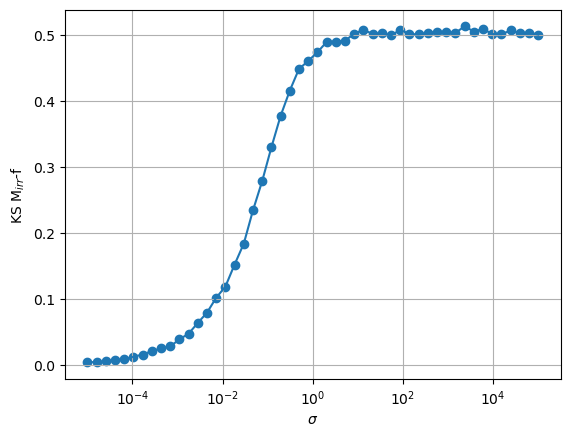

In [18]:
plt.grid(which='both')
plt.plot(sigmas, KSs_f)
plt.scatter(sigmas, KSs_f)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'KS M$_{irr}$-f')


Text(0, 0.5, 'KS M$_{irr}$-M')

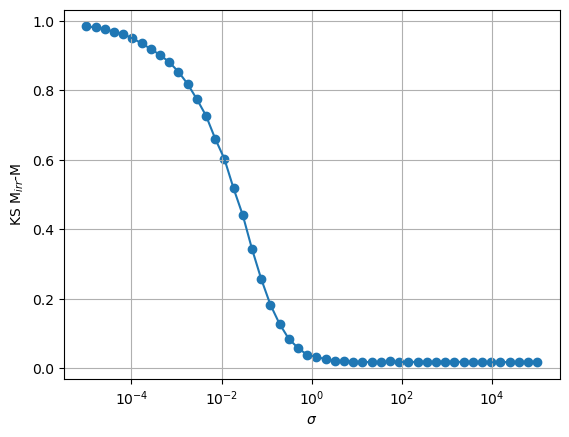

In [19]:
plt.grid(which='both')
plt.plot(sigmas, KSs_M)
plt.scatter(sigmas, KSs_M)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'KS M$_{irr}$-M')

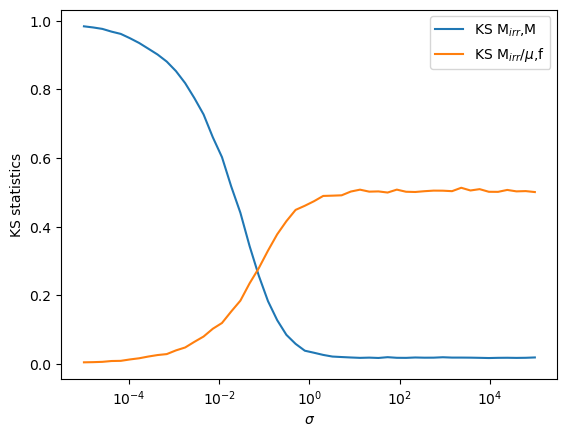

In [20]:
plt.plot(sigmas, KSs_M, label = r'KS M$_{irr}$,M')
plt.plot(sigmas, KSs_f, label = r'KS M$_{irr}/\mu$,f')
plt.xscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS statistics')
plt.legend();

In [21]:
# Mirr is distributed like f if sigma<<mu and Mirr is distributed like M if sigma>>mu
# mu is 1

In [22]:
from tqdm.notebook import tqdm

In [23]:
def p_f(f):
    return 2*(2*f**2-1)/np.sqrt(1-f**2)
def integrand(f,x):
    return ((2/np.pi)**0.5 / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f
def p_Mirr(f,x):
    return [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

N = 10000
x = np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,N)

Mirr_from_int = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

  0%|          | 0/10000 [00:00<?, ?it/s]

[]

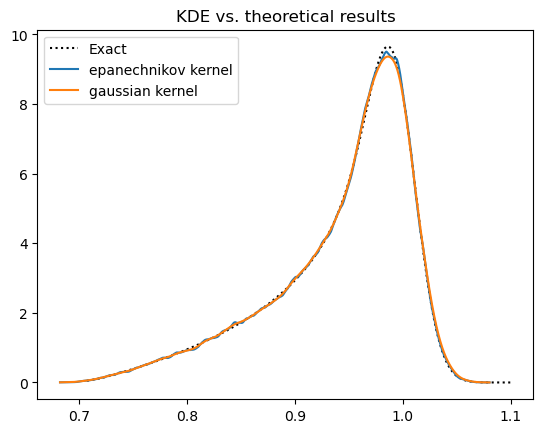

In [24]:
plt.plot(x,Mirr_from_int,label='Exact',c='black',ls=':')
PDFtophat = kde_sklearn(Mirr,bandwidth=0.005,kernel="epanechnikov") #fixed bw
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.005,kernel="gaussian") #fixed bw
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)

plt.title('KDE vs. theoretical results')
plt.legend()
plt.plot()